In [2]:
#import some libraries we are going to use in this project 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
#lets upload our data
df=pd.read_excel ("Global skincare and Beauty e-store_E-commerce Analysis_English.xlsx")
df.head(5)

,Row ID,Order ID,Order Date,Customer ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
0,46682,IZ-2012-LW699061-40911,2023-12-31,LW-699061,Corporate,Mosul,Ninawa,Iraq,33.223191,43.679291,Western Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Head & Shoulders Classic Clean Shampoo,20,600,0.0,300.0
1,10124,US-2012-BT1130518-40912,2023-12-31,BT-1130518,Self-Employed,Pilar,Alagoas,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Ultra Facial Overnight Hydrating Masque,2,40,0.6,-4.0
2,9067,MX-2012-AW1093031-40912,2023-12-31,AW-1093031,Self-Employed,Santiago de Cuba,Santiago de Cuba,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Golden Vine Bracelet,1,151,0.0,75.5
3,130,MX-2012-BT1130531-40912,2023-12-31,BT-1130531,Self-Employed,Manzanillo,Granma,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Crème de Corps Smoothing Oil-to-Foam B...,4,40,0.0,20.0
4,24072,IN-2012-KM1666027-40914,2023-12-31,KM-1666027,Consumer,Huadian,Jilin,China,35.861660,104.195397,Eastern Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,NARS Single Eyeshadow Sophia Cool Brown,1,11,0.0,5.5


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Customer ID', 'Segment', 'City',
       'State', 'Country', 'Country latitude', 'Country longitude', 'Region',
       'Market', 'Subcategory', 'Category', 'Product', 'Quantity', 'Sales',
       'Discount', 'Profit'],
      dtype='object')

# lets understand features of this data by explaining each column 

Order ID        : ID of the order (one order can have multiple items)
Order Date      : Date when order was made
Customer ID 	: ID of the customer (one customer can make multiple orders)
Segment	        : Customer segment 
City            : Order city
State           : Order state (where applicable)
Country	        : Order country
Country latitude:Geographic coordinates of the order country
Country longitude:Geographic coordinates of the order country
Region	        : Region to which the order belongs to
Market          : Market to which the order belongs to
Subcategory     : Productsubcategory
Category        : Product category
Product         : Product name
Quantity	    : Number of products purchased per order
Sales	        : Total sales in $
Discount    	: Discount applied to the order
Profit	        : Total profit for each order after discount

In [4]:
# lets visualize our data and make questions 
df.shape

(51290, 19)

In [ ]:
#from this code we recognise that this dataset has 51290 entery or order by customer each of them reflects sales according to country ,product and date 

In [5]:
df.dtypes

Row ID                        int64
Order ID                     object
Order Date           datetime64[ns]
Customer ID                  object
Segment                      object
City                         object
State                        object
Country                      object
Country latitude            float64
Country longitude           float64
Region                       object
Market                       object
Subcategory                  object
Category                     object
Product                      object
Quantity                      int64
Sales                         int64
Discount                    float64
Profit                      float64
dtype: object

In [5]:
#by  visualising  dataset  we recognised some unimportant columns won't solve any of our questions 
#columns to be dropped (row id 'order Id)
df.drop('Row ID', axis=1, inplace=True)
df.drop( 'Order ID', axis=1, inplace=True)

In [7]:
df.columns

Index(['Order Date', 'Customer ID', 'Segment', 'City', 'State', 'Country',
       'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit'],
      dtype='object')

In [8]:
df.shape

(51290, 17)

In [6]:
#using customer ID as the first column 

col =  'Customer ID'

df = df[[col] + [c for c in df.columns if c != col]]

In [7]:
df['Category'].unique()

array(['Body care', 'Face care', 'Hair care', 'Home and Accessories',
       'Make up'], dtype=object)

In [7]:
df['Country'].unique()

array(['Iraq', 'Brazil', 'Cuba', 'China', 'Hungary', 'New Zealand',
       'Mexico', 'United States', 'Italy', 'Mongolia', 'France',
       'Indonesia', 'Nigeria', 'Morocco', 'Netherlands', 'Senegal',
       'Guatemala', 'Poland', 'India', 'Myanmar [Burma]', 'Honduras',
       'Spain', 'Algeria', 'Switzerland', 'Iran', 'Austria', 'Russia',
       'Peru', 'Congo [DRC]', 'Afghanistan', 'Nicaragua', 'Germany',
       'South Korea', 'Portugal', 'Mozambique', 'Turkey', 'Australia',
       'Kazakhstan', 'Lesotho', 'El Salvador', 'Zimbabwe', 'Taiwan',
       'Thailand', 'South Africa', 'Sweden', 'Ireland', 'United Kingdom',
       'Panama', 'Azerbaijan', 'Egypt', 'Haiti', 'Philippines', 'Vietnam',
       'Dominican Republic', 'Bulgaria', 'Singapore', 'Israel',
       'Saudi Arabia', 'Canada', 'Japan', 'Ukraine', 'Argentina',
       'Pakistan', 'Venezuela', 'Bangladesh', 'Belarus', 'Malaysia',
       'Tanzania', 'Angola', 'Kyrgyzstan', 'Colombia', 'Cambodia',
       'Zambia', 'Kenya', 'Finland

In [13]:
df['Country'].value_counts()

Country
United States    9994
Australia        2837
France           2827
Mexico           2635
Germany          2063
                 ... 
Gambia              1
Suriname            1
Kuwait              1
Bhutan              1
Malawi              1
Name: count, Length: 164, dtype: int64

In [14]:
df['Product'].value_counts()

Product
Herbal Essences Bio                                       335
Neutrogena Hydro Boost Gel Cream                          227
Essie Nail Polish Aruba Blue Shimmering Cobalt             92
Head & Shoulders Classic Clean Conditioner                 90
Redken Color Extend Magnetics Conditioner                  84
                                                         ... 
Le Petit Marseillais Shea Butter & Acacia Shower Cream      1
Rose Gold Dream Earrings                                    1
Tom Ford Olympea                                            1
Kiehl's Superbly Restorative Argan Body Lotion              1
Aveda Stress-Fix Bath Soak                                  1
Name: count, Length: 3577, dtype: int64

Data cleaning for further visualization 


In [8]:
#as we  see order date containd time wich is not important to the project's point of view 
# so we may clean it and split order date to years and months 
df['month'] = df['Order Date'].apply(lambda x: x.month)
df['year'] = df['Order Date'].apply(lambda x: x.year)

In [11]:
df['Month_Name'] = pd.to_datetime(df['month'], format='%m').dt.month_name()
df.head()

,Customer ID,month,year,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit,Month_Name
0,LW-699061,12,2023,Corporate,Mosul,Ninawa,Iraq,33.223191,43.679291,Western Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Head & Shoulders Classic Clean Shampoo,20,600,0.0,300.0,December
1,BT-1130518,12,2023,Self-Employed,Pilar,Alagoas,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Ultra Facial Overnight Hydrating Masque,2,40,0.6,-4.0,December
2,AW-1093031,12,2023,Self-Employed,Santiago de Cuba,Santiago de Cuba,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Golden Vine Bracelet,1,151,0.0,75.5,December
3,BT-1130531,12,2023,Self-Employed,Manzanillo,Granma,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Crème de Corps Smoothing Oil-to-Foam B...,4,40,0.0,20.0,December
4,KM-1666027,12,2023,Consumer,Huadian,Jilin,China,35.861660,104.195397,Eastern Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,NARS Single Eyeshadow Sophia Cool Brown,1,11,0.0,5.5,December


In [17]:
#now we don't need date column
if ('Order Date') in df.columns:
    df.drop('Order Date', axis=1, inplace=True)
if ('month') in df.columns:
    df.drop('month',axis=1,inplace=True)

In [14]:
df = df[[ 'Customer ID','Month_Name','year' ,'Segment', 'City',
       'State', 'Country', 'Country latitude', 'Country longitude', 'Region',
       'Market', 'Subcategory', 'Category', 'Product', 'Quantity', 'Sales',
       'Discount', 'Profit']]

In [15]:
df.head()

,Customer ID,Month_Name,year,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
0,LW-699061,December,2023,Corporate,Mosul,Ninawa,Iraq,33.223191,43.679291,Western Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Head & Shoulders Classic Clean Shampoo,20,600,0.0,300.0
1,BT-1130518,December,2023,Self-Employed,Pilar,Alagoas,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Ultra Facial Overnight Hydrating Masque,2,40,0.6,-4.0
2,AW-1093031,December,2023,Self-Employed,Santiago de Cuba,Santiago de Cuba,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Golden Vine Bracelet,1,151,0.0,75.5
3,BT-1130531,December,2023,Self-Employed,Manzanillo,Granma,Cuba,21.521757,-77.781167,Caribbean,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Crème de Corps Smoothing Oil-to-Foam B...,4,40,0.0,20.0
4,KM-1666027,December,2023,Consumer,Huadian,Jilin,China,35.861660,104.195397,Eastern Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,NARS Single Eyeshadow Sophia Cool Brown,1,11,0.0,5.5


In [8]:
df.isna().sum()

Customer ID          0
Segment              0
City                 0
State                0
Country              0
Country latitude     0
Country longitude    0
Region               0
Market               0
Subcategory          0
Category             0
Product              0
Quantity             0
Sales                0
Discount             0
Profit               0
month                0
year                 0
dtype: int64

In [ ]:
#as seen there is no null values in our dataset that means we dont need to use to fill it with mean ,median or mode 

In [15]:
#searching for dublicates
df.duplicated().sum()

np.int64(2)

In [20]:
#dropping duplicates
df.drop_duplicates(inplace=True)


C:\Users\dell\AppData\Local\Temp\ipykernel_22716\2895614389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [19]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51288 entries, 0 to 51289
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        51288 non-null  object 
 1   month              51288 non-null  int64  
 2   year               51288 non-null  int64  
 3   Segment            51288 non-null  object 
 4   City               51288 non-null  object 
 5   State              51288 non-null  object 
 6   Country            51288 non-null  object 
 7   Country latitude   51288 non-null  float64
 8   Country longitude  51288 non-null  float64
 9   Region             51288 non-null  object 
 10  Market             51288 non-null  object 
 11  Subcategory        51288 non-null  object 
 12  Category           51288 non-null  object 
 13  Product            51288 non-null  object 
 14  Quantity           51288 non-null  int64  
 15  Sales              51288 non-null  int64  
 16  Discount           51288 no

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51288 entries, 0 to 51287
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        51288 non-null  object 
 1   Month_Name         51288 non-null  object 
 2   year               51288 non-null  int64  
 3   Segment            51288 non-null  object 
 4   City               51288 non-null  object 
 5   State              51288 non-null  object 
 6   Country            51288 non-null  object 
 7   Country latitude   51288 non-null  float64
 8   Country longitude  51288 non-null  float64
 9   Region             51288 non-null  object 
 10  Market             51288 non-null  object 
 11  Subcategory        51288 non-null  object 
 12  Category           51288 non-null  object 
 13  Product            51288 non-null  object 
 14  Quantity           51288 non-null  int64  
 15  Sales              51288 non-null  int64  
 16  Discount           512

In [23]:
df.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Country', 'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit'],
      dtype='object')

In [21]:
#visualization of customers
df['Customer ID'].value_counts()

Customer ID
SV-203651406    26
WB-218501404    24
AP-109151404    23
EM-1396082      21
CS-121757       20
                ..
HG-1496597       1
MV-1748559       1
ED-1388518       1
TT-11220129      1
DM-129551408     1
Name: count, Length: 17415, dtype: int64

In [24]:
#making dataframe showing customers wich made orders more than 20 
df_customer = df[df['Customer ID'].isin(
    df['Customer ID'].value_counts()[lambda x: x > 21].index)]
df_customer 

,Customer ID,Month_Name,year,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
2677,AP-109151404,November,2023,Consumer,Los Angeles,California,United States,37.09024,-95.712891,Western US,USCA,body moisturizers,Body care,Clarins Tonic Body Treatment Oil,4,44,0.0,4.4
4660,SV-203651406,October,2023,Consumer,New York City,New York,United States,37.09024,-95.712891,Eastern US,USCA,body moisturizers,Body care,Anastasia Beverly Hills Brow Wiz Ebony,2,16,0.0,1.6
5167,AP-109151404,October,2023,Consumer,Los Angeles,California,United States,37.09024,-95.712891,Western US,USCA,Body soaps and washes,Body care,L'Oréal Paris Colour Riche Nail Color Spice Th...,2,16,0.2,4.8
5194,WB-218501404,October,2023,Consumer,Los Angeles,California,United States,37.09024,-95.712891,Western US,USCA,Body soaps and washes,Body care,Maybelline Your Skin But Better CC+ Cream,4,136,0.2,40.8
6677,AP-109151404,September,2023,Consumer,Denver,Colorado,United States,37.09024,-95.712891,Western US,USCA,face masks and exfoliators,Body care,L'Occitane Verbena Cooling Hand Cream Gel,1,28,0.2,-2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49237,AP-109151404,May,2020,Consumer,Fort Collins,Colorado,United States,37.09024,-95.712891,Western US,USCA,foundations and concealers,Make up,L'Oréal Paris Colour Riche Nail Color Spice Th...,2,16,0.7,-4.8
50051,WB-218501404,March,2020,Consumer,Redmond,Oregon,United States,37.09024,-95.712891,Western US,USCA,Lipsticks,Make up,Optimum Nutrition Iron Supplement,4,136,0.2,40.8
50672,AP-109151404,February,2020,Consumer,Seattle,Washington,United States,37.09024,-95.712891,Western US,USCA,Lipsticks,Make up,O'Keeffe's Working Hands Hand Cream Unscented,3,60,0.0,30.0
50673,AP-109151404,February,2020,Consumer,Seattle,Washington,United States,37.09024,-95.712891,Western US,USCA,Lipsticks,Make up,Anastasia Beverly Hills Brow Definer Soft Brown,3,36,0.0,18.0


In [25]:
df_customer['Market'].unique()


array(['USCA'], dtype=object)

In [26]:
df_customer['Country'].unique()

array(['United States'], dtype=object)

In [ ]:
#by observation we can see that customers who made highest number of orders are all customers and purchased from USCA market in united states 



In [ ]:
Now we have clean data no null values no dublicates 
lets visualise each feature helps us in understanding data distribution 

In [27]:
df[['Quantity','Sales', 'Discount', 'Profit']].describe()

,Quantity,Sales,Discount,Profit
count,51288.000000,51288.000000,51288.000000,51288.000000
mean,5.415906,127.079258,0.142890,20.773390
std,4.908314,236.078356,0.212261,83.584141
min,1.000000,2.000000,0.000000,-1746.000000
25%,2.000000,25.000000,0.000000,0.000000
50%,4.000000,56.000000,0.000000,7.200000
75%,7.000000,132.000000,0.200000,25.000000
max,20.000000,3940.000000,0.850000,1820.000000


by observation we can see that customers who made highest number of orders are all customers and purchased from USCA market 

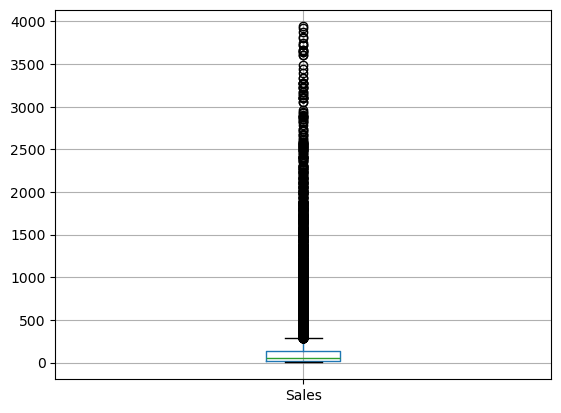

In [9]:
#box plot of some features to understand data distribution 
df.boxplot(column=["Sales"])
plt.show()

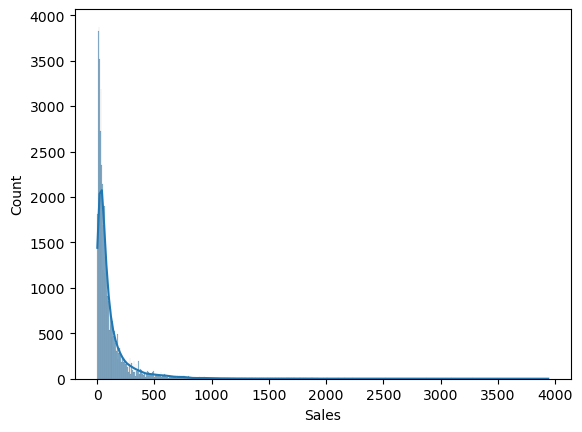

In [29]:
sns.histplot(df["Sales"], kde=True)
plt.show()

#data is  right skewed and has too much outliers

In [11]:
#count no of sales outliers 

Q1s = df['Sales'].quantile(0.25)
Q3s = df['Sales'].quantile(0.75)
IQRs = Q3s - Q1s

outliers_S = df[(df['Sales'] < Q1s - 1.5*IQRs) |
                (df['Sales'] > Q3s + 1.5*IQRs)]

len(outliers_S)

5126

that means that sales outliers are 1/10 of the data and this is big number  cann't be dropped as it may contain useful signs in out data 

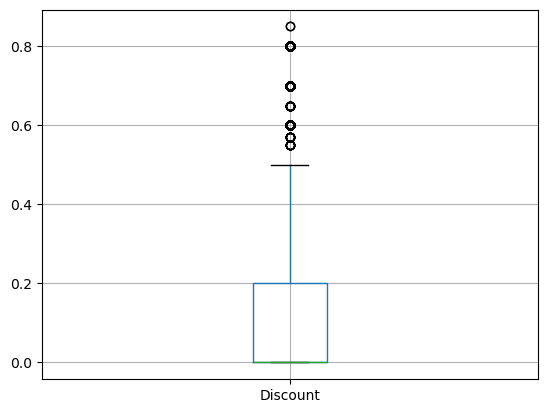

In [13]:
df.boxplot(column=["Discount"])
plt.show()

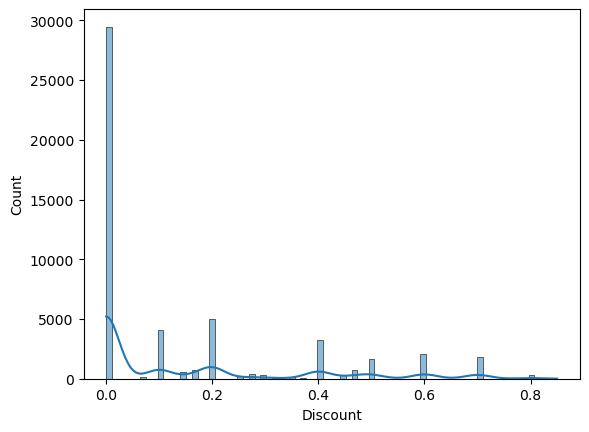

In [30]:
sns.histplot(df["Discount"], kde=True)
plt.show()

In [ ]:
visualization of discounts outliers

In [31]:
#lets make dataframe shows outliers of discount values
Q1d = df["Discount"].quantile(0.25)
Q3d = df["Discount"].quantile(0.75)
IQRd = Q3d - Q1d

lower_boundd = Q1d - 1.5 * IQRd
upper_boundd = Q3d + 1.5 * IQRd

# Get outlier rows
outliers_d = df[(df["Discount"] < lower_boundd) | (df["Discount"] > upper_boundd)]

outliers_d

,Customer ID,Month_Name,year,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
1,BT-1130518,December,2023,Self-Employed,Pilar,Alagoas,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Kiehl's Ultra Facial Overnight Hydrating Masque,2,40,0.6,-4.0
18,DP-316595,December,2023,Consumer,Kano,Kano,Nigeria,9.081999,8.675277,Western Africa,Africa,"bath oils, bubbles and soaks",Body care,Maybelline Color Tattoo 24HR Eyeshadow Fierce ...,1,14,0.7,-2.8
53,DW-1348018,December,2023,Self-Employed,Limoeiro do Norte,Ceará,Brazil,-14.235004,-51.925280,South America,LATAM,"bath oils, bubbles and soaks",Body care,Revlon Colorsilk - Ultra Light Sun Blonde,2,40,0.6,-4.0
76,MB-8085134,December,2023,Consumer,Balikesir,Balikesir,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,Zoya Nail Polish Jacqueline Soft Cream,2,16,0.6,-1.6
78,JM-553568,December,2023,Consumer,Astana,Astana,Kazakhstan,48.019573,66.923684,Central Asia,Asia Pacific,"bath oils, bubbles and soaks",Body care,NARS Larger Than Life Long-Wear Eyeliner Barro...,2,38,0.7,-7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51249,PF-922595,January,2020,Consumer,Ibadan,Oyo,Nigeria,9.081999,8.675277,Western Africa,Africa,Lipsticks,Make up,Wella Koleston Perfect - Soft Red Blonde,2,26,0.7,-7.8
51253,LC-171401402,January,2020,Consumer,Dallas,Texas,United States,37.090240,-95.712891,Central US,USCA,Lipsticks,Make up,BareMinerals Perfecting Face Brush,2,6,0.8,-2.4
51255,JK-609095,January,2020,Consumer,Lagos,Lagos,Nigeria,9.081999,8.675277,Western Africa,Africa,Lipsticks,Make up,Anastasia Beverly Hills Brow Wiz Medium Brown,8,72,0.7,-21.6
51265,MM-179201402,January,2020,Consumer,College Station,Texas,United States,37.090240,-95.712891,Central US,USCA,Lipsticks,Make up,Anastasia Beverly Hills Norvina Eyeshadow Pale...,8,56,0.8,-22.4


In [33]:
outliers_d ['Month_Name'].unique()

array(['December', 'November', 'October', 'September', 'August', 'July',
       'June', 'May', 'April', 'March', 'February', 'January'],
      dtype=object)

In [34]:
outliers_d ['Month_Name'].value_counts()

Month_Name
June         474
December     450
May          438
November     414
September    356
October      325
March        316
January      312
August       307
April        293
February     257
July         229
Name: count, dtype: int64

In [36]:
#further visualization to june outliers
june_discounts= outliers_d[outliers_d ['Month_Name']=='June']
june_discounts

,Customer ID,Month_Name,year,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
10716,RR-1952518,June,2023,Corporate,Belo Horizonte,Minas Gerais,Brazil,-14.235004,-51.925280,South America,LATAM,hand creams,Body care,Neutrogena Body Clear Body Wash,12,132,0.6,-26.4
10726,RL-961568,June,2023,Consumer,Temirtau,Qaraghandy,Kazakhstan,48.019573,66.923684,Central Asia,Asia Pacific,hand creams,Body care,Fenty Beauty Your Skin But Better CC+ Cream,4,120,0.7,-36.0
10745,AY-555134,June,2023,Corporate,Trabzon,Trabzon,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,hand creams,Body care,Garnier Nutrisse Ultra Color - Medium Golden B...,1,15,0.6,-3.0
10779,OT-873068,June,2023,Consumer,Qostanay,Qostanay,Kazakhstan,48.019573,66.923684,Central Asia,Asia Pacific,hand creams,Body care,Nordic Naturals Iron Supplement,1,41,0.7,-12.3
10791,RD-9810134,June,2023,Self-Employed,Batman,Batman,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,hand creams,Body care,Sally Hansen Insta-Dri Rapid Red Bright Red,3,15,0.6,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48693,BF-1275134,June,2020,Corporate,Bursa,Bursa,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,foundations and concealers,Make up,Chanel Rouge Coco Mademoiselle,9,63,0.6,-6.3
48695,BT-1440134,June,2020,Consumer,Istanbul,Istanbul,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,foundations and concealers,Make up,Eucerin Smoothing Repair Lotion,1,31,0.6,-3.1
48696,BT-1440134,June,2020,Consumer,Istanbul,Istanbul,Turkey,38.963745,35.243322,Western Asia,Asia Pacific,foundations and concealers,Make up,L'Oréal Paris Age Perfect Hydra-Nutrition Hone...,4,84,0.6,-8.4
48729,TC-1098095,June,2020,Corporate,Aba,Abia,Nigeria,9.081999,8.675277,Western Africa,Africa,foundations and concealers,Make up,Too Faced Natural Eyes Palette Push-Up,3,45,0.7,-13.5


In [37]:
june_discounts['year'].value_counts()

year
2023    203
2022    141
2020     71
2021     59
Name: count, dtype: int64

In [38]:
df.groupby('Month_Name')[ "Discount"].sum().sort_values(ascending=False)

Month_Name
December     877.350
November     862.770
June         798.830
September    732.490
August       661.000
October      603.090
May          602.280
January      480.960
July         452.720
March        448.244
April        426.258
February     382.536
Name: Discount, dtype: float64

by deep analysis to discounts column we can see that most outliers of discounts are in june  mainly june 2023    but highest value are in december 

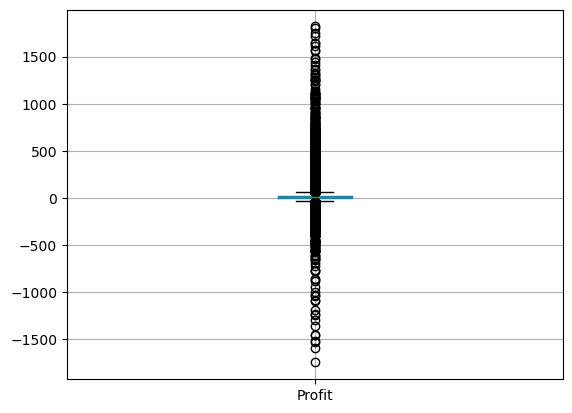

In [59]:
df.boxplot(column=["Profit"])
plt.show()

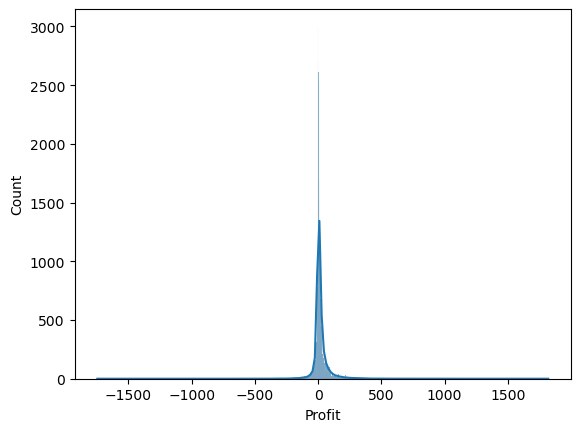

In [39]:
sns.histplot(df["Profit"], kde=True)
plt.show()

In [40]:

#count profit outliers 
Q1p = df['Profit'].quantile(0.25)
Q3p = df['Profit'].quantile(0.75)
IQRp = Q3p - Q1p

outliers_p = df[(df['Profit'] < Q1p - 1.5*IQRp) |
                (df['Profit'] > Q3p + 1.5*IQRp)]

len(outliers_p)

7740

7740 is large number  so we won't drop it

by revising all outliers of sales ,discount and profit  it recorded  high number of enteries wich cann't be dropped

In [ ]:
#lets observe distribution of numerical values by using histograms 

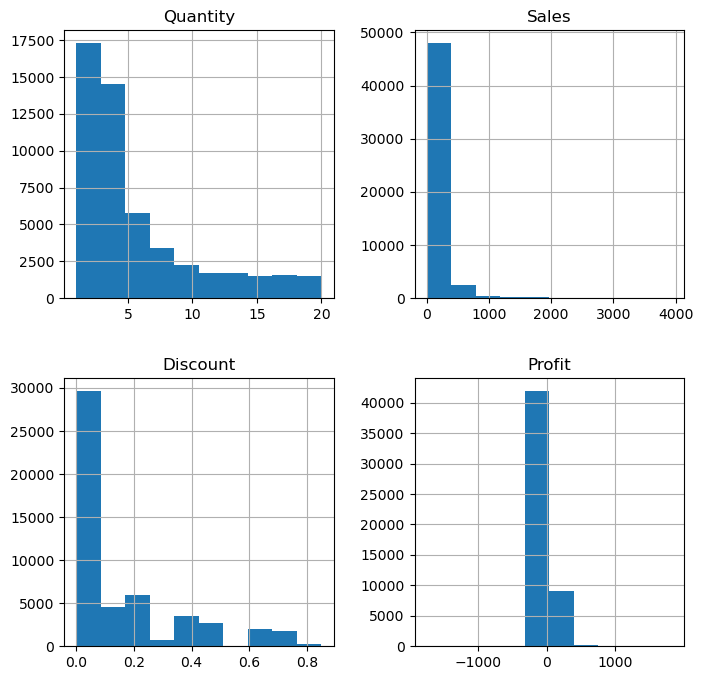

In [128]:
df[['Quantity','Sales', 'Discount', 'Profit']].hist(figsize=(8,8));
plt.show()

In [41]:
# Split the dataset into profit and loss to make insights
df_p = df[df['Profit']>0]
df_l = df[df['Profit']<0]

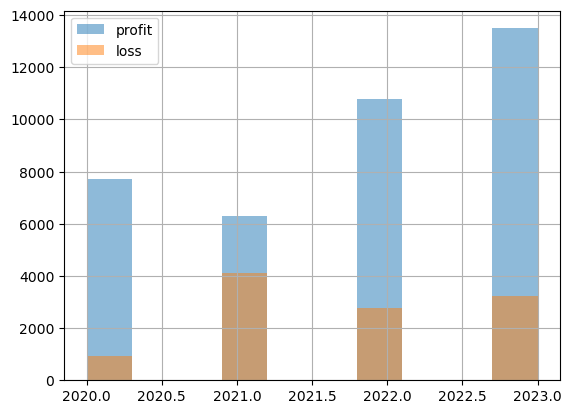

In [42]:

# plot histogram for years  of profit and loss
df_p['year'].hist(alpha=0.5, label='profit')
df_l['year'].hist(alpha=0.5, label='loss')

plt.legend()
plt.show()

as showen above profit is the best in 2023
and is  the worst in 2021 may be due to covid panademic  but overall profit is more than loss in all years

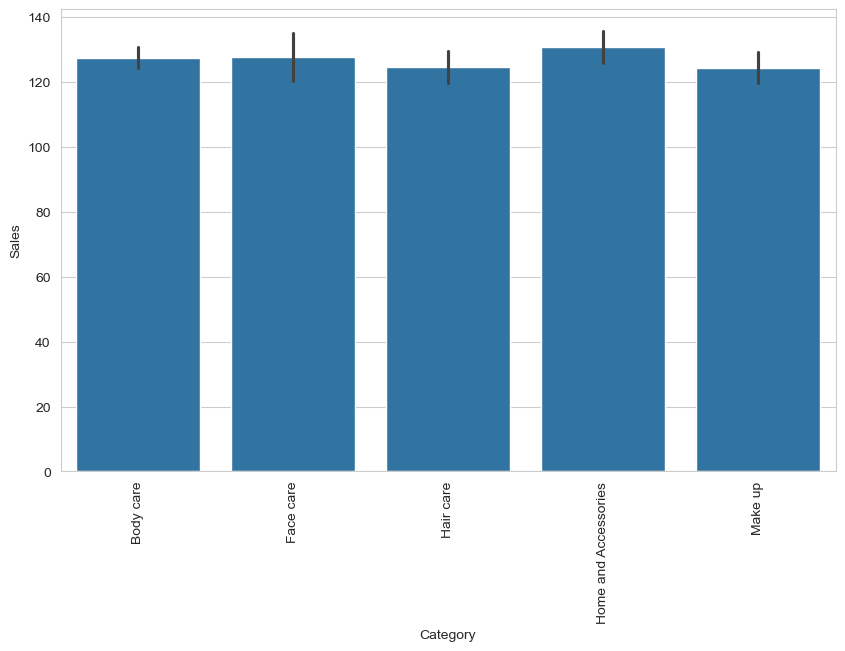

In [76]:
# drawing bar plot of categories :
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
plt.xticks(rotation=90)
sns.barplot(x='Category', y='Sales', data=df);
plt.show()

In [ ]:
#1-	What category of product is the most distributed so we can make it our start 

In [16]:
df['Subcategory'].value_counts()

Subcategory
Nail care products              6145
shampoos and conditioners       5049
Eye shadows and pencils         4864
face moisturizing products      3492
vitamins and supplements        3434
brushes and applicators         3356
hair colors and toners          3154
Accessories                     3075
body moisturizers               2601
hand creams                     2601
foundations and concealers      2411
face masks and exfoliators      2407
bath oils, bubbles and soaks    2387
candles, sprays, diffusers      2223
Lipsticks                       1742
Body soaps and washes           1486
fragrances                       861
Name: count, dtype: int64

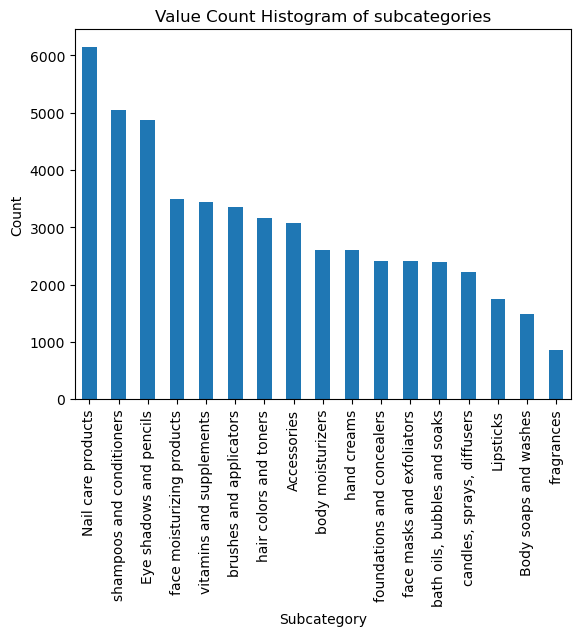

In [42]:
df['Subcategory'].value_counts().plot(kind='bar')
plt.xlabel('Subcategory')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('Value Count Histogram of subcategories')
plt.show()

In [28]:
#we can observe that nailcare products is the best seller  while fragrances are the worst may be due to it's price
# so the next step lets see  the profit of this subcategory 


In [23]:

df.groupby('Subcategory')[ 'Profit'].sum().sort_values(ascending=False)

Subcategory
Nail care products              223692.49
Eye shadows and pencils         203809.91
face moisturizing products      159018.10
vitamins and supplements        135023.12
hand creams                     113138.41
bath oils, bubbles and soaks     99583.15
foundations and concealers       97773.45
Lipsticks                        67414.82
Body soaps and washes            47532.83
shampoos and conditioners         3124.52
hair colors and toners             552.71
Accessories                      -4099.50
candles, sprays, diffusers       -4637.41
face masks and exfoliators       -9815.90
body moisturizers               -18237.92
brushes and applicators         -21707.01
fragrances                      -26740.12
Name: Profit, dtype: float64

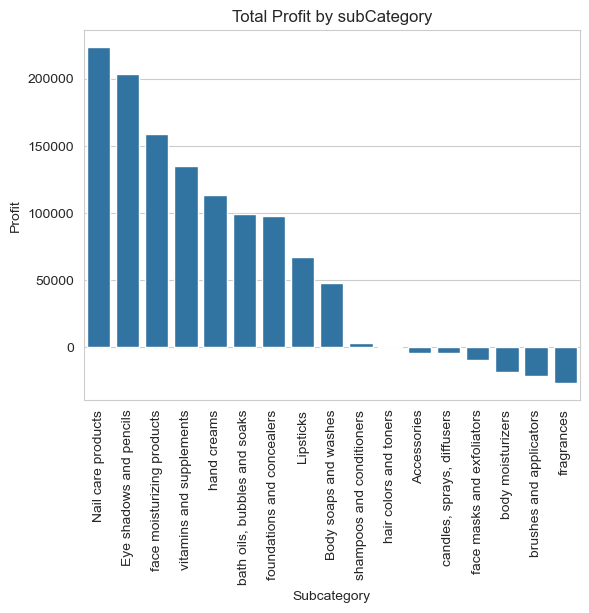

In [27]:
profit_per_category = (
    df.groupby('Subcategory')['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit', ascending=False)
)

sns.barplot(data=profit_per_category, x='Subcategory', y='Profit')
plt.xticks(rotation=90)
plt.title('Total Profit by subCategory')
plt.show()

observation:nail care product is the best seller and also highest profit while fragrances profit is negative wich needs further understanding according to each specific country l

2-	What is the reflection of the region on the category of the product 

Latitude

What it measures: How far north or south a place is from the Equator
we will create a new column that shows how far each product’s country is from the Equator.
for temperature, what matters is:

how far the place is from the Equator, not whether it’s north or south.

So:

+10° and -10° are treated the same

In [43]:
df["latitude"] = df['Country latitude'].abs()

In [44]:
bins = [0, 15, 30, 45, 60, 90]
labels = ["0–15°", "15–30°", "30–45°", "45–60°", "60–90°"]

df["latitude_range"] = pd.cut(
    df["latitude"], bins=bins,labels=labels,include_lowest=True)

In [45]:
df["latitude_range"] = pd.Categorical(df["latitude_range"],categories=labels,ordered=True)


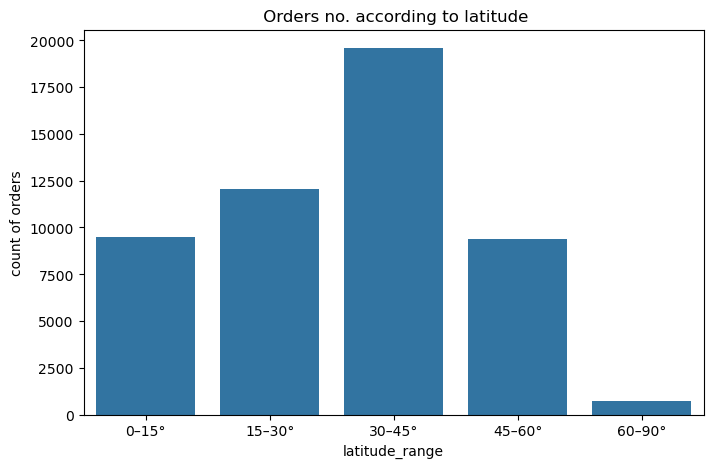

In [46]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="latitude_range")

plt.xlabel("latitude_range")
plt.ylabel("count of orders")
plt.title(" Orders no. according to latitude")

plt.show()

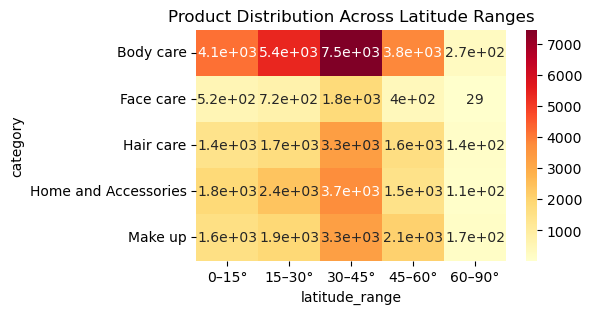

In [47]:
pivot = pd.crosstab(df['Category'], df["latitude_range"])

plt.figure(figsize=(5, 3))
sns.heatmap(pivot, annot=True, cmap="YlOrRd")

plt.title("Product Distribution Across Latitude Ranges")
plt.xlabel('latitude_range')
plt.ylabel("category")

plt.show()

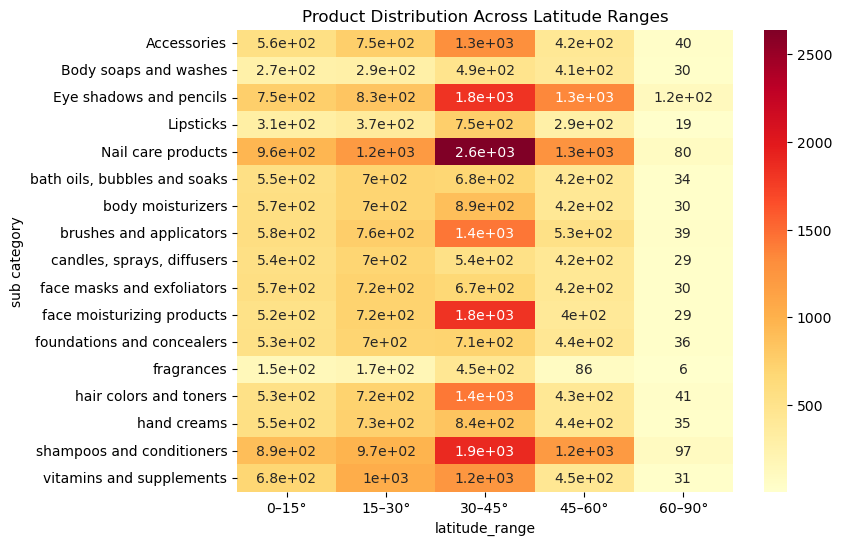

In [23]:
sub_pivot = pd.crosstab(df['Subcategory'], df["latitude_range"])

plt.figure(figsize=(8, 6))
sns.heatmap(sub_pivot, annot=True, cmap="YlOrRd")

plt.title("Product Distribution Across Latitude Ranges")
plt.xlabel("latitude_range")
plt.ylabel("sub category")

plt.show()

obsservation : Egypt lies roughly between:22∘N to 31.5∘N
 so we can observe from this heatmap  that best seller  products  sold in weather  matchs our's  is 
1-nail care products ,2-eye shadow and pencils,3-face  moisturizing ,4-shampoos and conditioners 

In [46]:
#working on longitude ranges:
df['longitude'] = df['Country longitude'].abs()
bins2 = [0, 15, 30, 45, 60, 90,100,200,1000]
labels2 = ["0–15°", "15–30°", "30–45°", "45–60°", "60–90°","90-100","100-200",'200-1000']

df['longitude_range'] = pd.cut(
    df['longitude'], bins=bins2,labels=labels2,include_lowest=True)
df['longitude_range'] = pd.Categorical(df['longitude_range'],categories=labels,ordered=True)

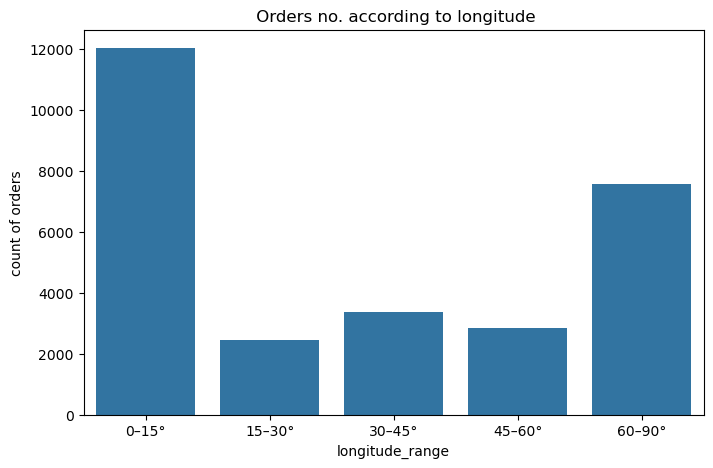

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x='longitude_range')

plt.xlabel('longitude_range')
plt.ylabel("count of orders")
plt.title(" Orders no. according to longitude")

plt.show()

In [47]:
df.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Country', 'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit', 'latitude', 'latitude_range', 'longitude', 'longitude_range'],
      dtype='object')

In [ ]:
 3-	who are our target audience  which segment of customers  who makes high sales 

In [5]:
df['Segment'].value_counts()

Segment
Consumer         26518
Corporate        15429
Self-Employed     9343
Name: count, dtype: int64

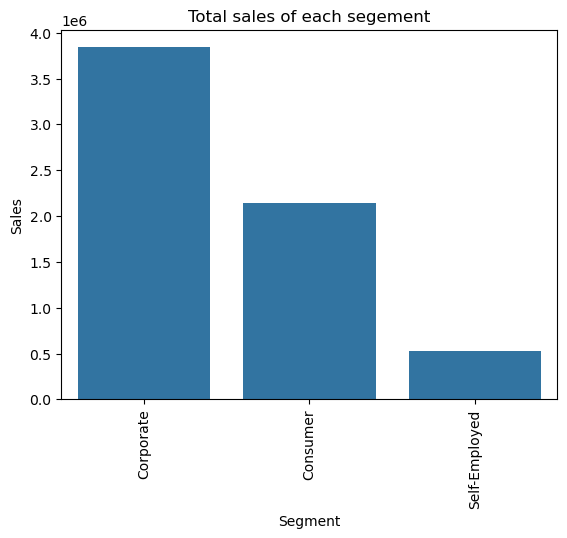

In [49]:
df_segment = (
    df.groupby('Segment')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
)

sns.barplot(data= df_segment, x='Segment', y='Sales')
plt.xticks(rotation=90)
plt.title('Total sales of each segement')
plt.show()

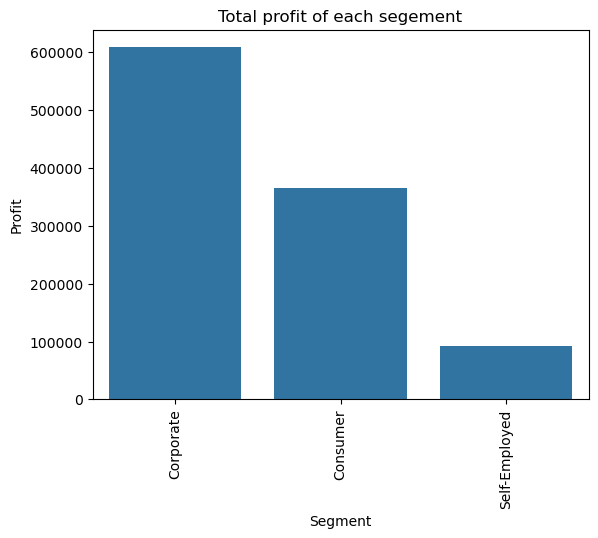

In [50]:
df_segment_profit = (
    df.groupby('Segment')['Profit'].sum().reset_index().sort_values('Profit', ascending=False)
)

sns.barplot(data= df_segment_profit, x='Segment', y='Profit')
plt.xticks(rotation=90)
plt.title('Total profit of each segement')
plt.show()

observation :However consumer recorded highest number of orders but corporate  had the best  total sales and total profit   that gives us clear insight about our   target audience and advertising plan

5-	Which season is the best   for each product or category 

In [16]:
df['Month_Name'].value_counts(ascending=False)

Month_Name
November     6311
December     6257
September    5958
June         5302
August       5065
October      4556
May          3787
July         3195
April        3032
March        3007
January      2611
February     2209
Name: count, dtype: int64

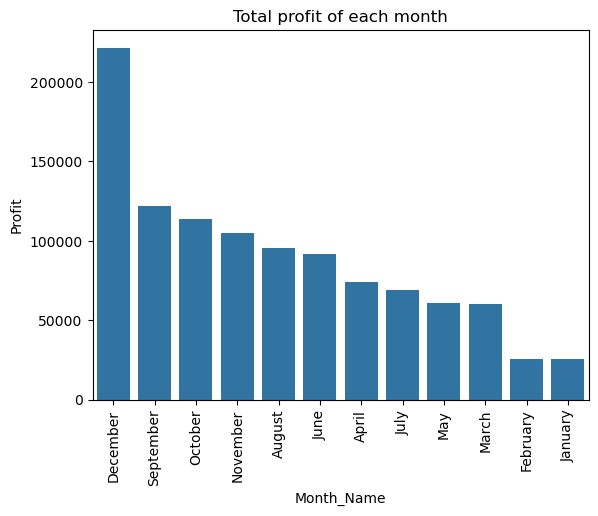

In [51]:
best_season = (
    df.groupby('Month_Name')['Profit'].sum().reset_index().sort_values('Profit', ascending=False)
)

sns.barplot(data=best_season , x='Month_Name', y='Profit')
plt.xticks(rotation=90)
plt.title('Total profit of each month')
plt.show()

observation :december made the best profit,while november recorded highest no.of order  so we can assume that winter is the best season for market trend

does discount affects  quantity ?

<Axes: xlabel='Quantity', ylabel='Discount'>

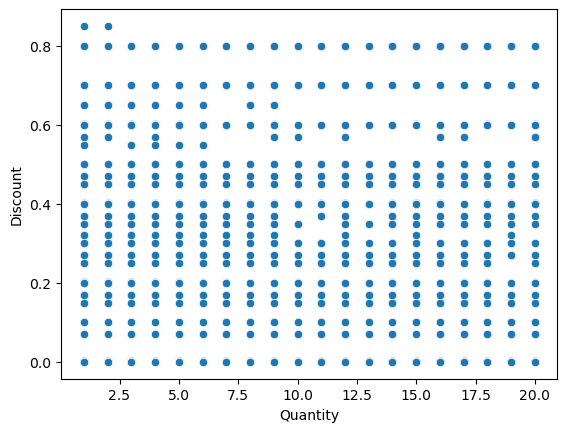

In [24]:
#correlation between quantily and discount 
sns.scatterplot(x='Quantity', y='Discount', data=df)

<Axes: xlabel='Profit', ylabel='Discount'>

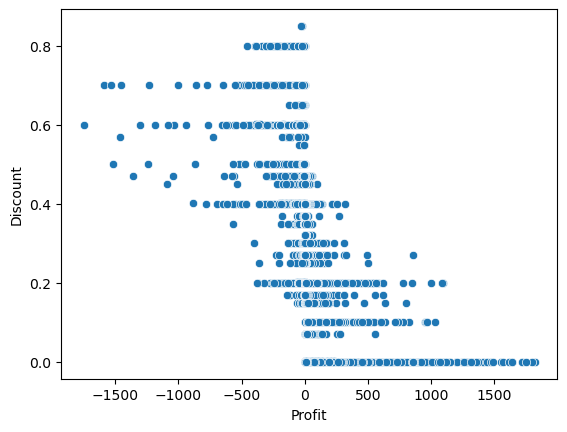

In [26]:
#correlation between discount and profit 
sns.scatterplot(x='Profit', y='Discount', data=df)

discount doesnt affect quantity which doesn't makesense so this  needs further specialisation 

In [52]:
df.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Country', 'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit', 'latitude', 'latitude_range', 'longitude', 'longitude_range'],
      dtype='object')

In [53]:
#exclude dataframe with numeric values
df_numericc=df[['Quantity','Sales', 'Discount', 'Profit']]
df_numericc.head()

,Quantity,Sales,Discount,Profit
0,20,600,0.0,300.0
1,2,40,0.6,-4.0
2,1,151,0.0,75.5
3,4,40,0.0,20.0
4,1,11,0.0,5.5


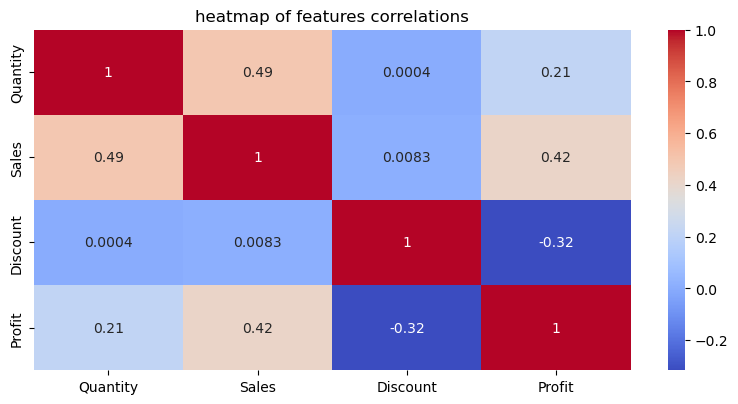

In [119]:
#heatmap of numeric values:
plt.figure(figsize=(8,4))
sns.heatmap(df_numericc.corr(),annot=True,cmap='coolwarm')
plt.tight_layout()
plt.title("heatmap of features correlations")
plt.show()

from this heatmap we can visualise that correlation between catogeries is not  strong 

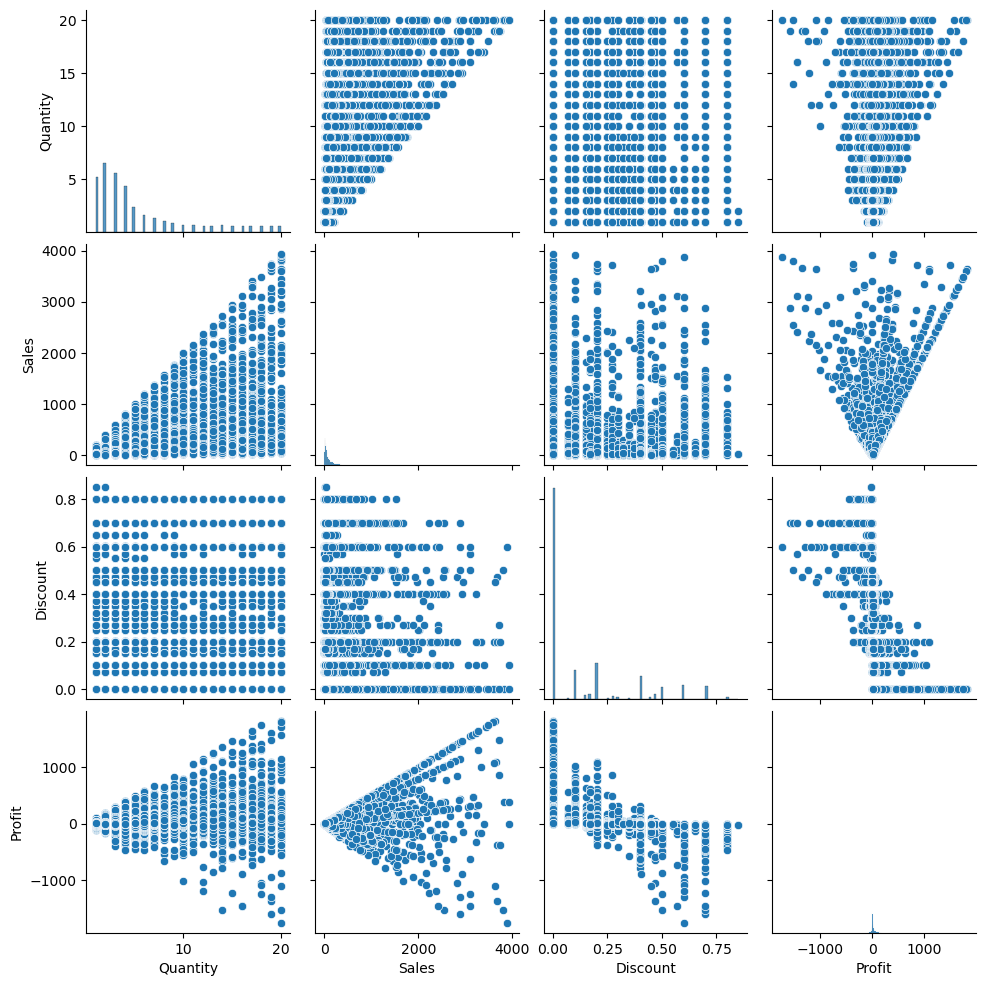

In [55]:
import seaborn as sns
sns.pairplot(df_numericc);
plt.show()


i have dataset wich has many outliers, categorical values and  low correlation how can i make regression to this dataset

so Best practice for our  case since  dataset has:

outliers

categorical variables

low correlation

 so Best choice:

Encoding + Tree-based regression
(Random Forest / Gradient Boosting)

In [56]:
df.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Country', 'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit', 'latitude', 'latitude_range', 'longitude', 'longitude_range'],
      dtype='object')

In [61]:
#define our data:
X=df[['Country','Market','year', 'Month_Name','Subcategory','Quantity','Segment','Sales','Discount']]
y=df['Profit']



#handeling datafor encoding :

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols=['Country','Market', 'Subcategory','Month_Name','Segment']
numeric_cols=['Quantity','Sales','Discount','year']
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),('num', 'passthrough', numeric_cols)])


In [62]:

X_encoded = preprocessor.fit_transform(X)

In [63]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200,random_state=42)


In [64]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [66]:
y_pred = model.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3.330947450944212


In [68]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.9415310941094659


In [69]:
#let's try other type of regression models(ridge)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


Ridge()

In [70]:
y_pred = ridge.predict(X_test)
print(f"R² Score (Ridge): {r2_score(y_test, y_pred):.4f}")

R² Score (Ridge): 0.3887


In [71]:
#polynomial regression model:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [72]:
y_pred = poly_model.predict(X_test)
print(f"R² Score (Polynomial): {r2_score(y_test, y_pred):.4f}")

R² Score (Polynomial): 0.9898


In [73]:
# Compare models
models = {
    
    "Ridge": Ridge(alpha=1.0).fit(X_train, y_train),
    
    "Random_forest":model.fit(X_train, y_train),
    "Polynomial": poly_model
    
}
for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"{name} R²: {r2_score(y_test, y_pred):.4f} | MSE: {mean_squared_error(y_test, y_pred):.2f}")

Ridge R²: 0.3887 | MSE: 4428.49
Random_forest R²: 0.9415 | MSE: 423.54
Polynomial R²: 0.9898 | MSE: 73.61


 polynomial and then random forest are the best models for this data set 

I will target Sales instead of Profit because Profit is influenced by additional factors such as raw material costs, production expenses, and shipping costs, which are not available in this dataset. Therefore, Sales is the most reliable and measurable variable here, and it can later be compared with Profit for further analysis.


In [61]:
df.columns

Index(['Customer ID', 'month', 'year', 'Segment', 'City', 'State', 'Country',
       'Country latitude', 'Country longitude', 'Region', 'Market',
       'Subcategory', 'Category', 'Product', 'Quantity', 'Sales', 'Discount',
       'Profit', 'latitude', 'latitude_range', 'Month_Name'],
      dtype='object')

In [87]:
#define our data:
Xs=df[['Country','Market','year', 'Month_Name','Subcategory','Quantity','Segment','Discount']]
ys=df['Sales']



#handeling datafor encoding :

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_colss=['Country','Market', 'Subcategory','Month_Name','Segment']
numeric_colss=['Quantity','Discount','year']
preprocessors = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_colss),('num', 'passthrough', numeric_colss)])


In [121]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Country','Market','Subcategory','Month_Name','Segment']
numeric_cols = ['Quantity','Discount','year']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)


In [122]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [123]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Market',
                                                   'Subcategory', 'Month_Name',
                                                   'Segment']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Discount',
                                                   'year'])])),
                ('regressor', LinearRegression())])

In [124]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.24956647298210966
MAE: 90.85831202616329
RMSE: 205.57471239082093


In [88]:
X_encodeds = preprocessors.fit_transform(Xs)

In [97]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_encodeds, ys, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200,random_state=42)

In [98]:
model.fit(Xs_train, ys_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [99]:
ys_pred = model.predict(Xs_test)

In [100]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(ys_test, ys_pred)
print("MAE:", mae)

MAE: 99.3113880759269


In [101]:
from sklearn.metrics import r2_score

r2s = r2_score(ys_test, ys_pred)
print("R² randomforest sales:", r2s)

R² randomforest sales: 0.07296528977176087


In [102]:
#let's try other type of regression models(ridge)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_encodeds, ys, test_size=0.2, random_state=42)
ridge = Ridge(alpha=1.0)
ridge.fit(Xs_train, ys_train)


Ridge()

In [103]:
ys_pred = ridge.predict(Xs_test)
print(f"R² Score (Ridge)s: {r2_score(ys_test, ys_pred):.4f}")

R² Score (Ridge)s: 0.2496


In [95]:
#polynomial regression model:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(Xs_train, ys_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [104]:
ys_pred = poly_model.predict(Xs_test)
print(f"R² Score (Polynomial): {r2_score(ys_test, ys_pred):.4f}")

R² Score (Polynomial): 0.2446


In [85]:
# Compare models
models = {
    
    "Ridge": Ridge(alpha=1.0).fit(X_train, y_train),
    
    "Random_forest":model.fit(X_train, y_train),
    "Polynomial": poly_model
    
}
for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"{name} R²: {r2_score(y_test, y_pred):.4f} | MSE: {mean_squared_error(y_test, y_pred):.2f}")

Ridge R²: 0.2496 | MSE: 42258.28
Random_forest R²: 0.0730 | MSE: 52206.33
Polynomial R²: 0.2446 | MSE: 42540.22


let's make a focus on egypt


In [105]:
df_egy=df[df['Country']=='Egypt']
df_egy

,Customer ID,Month_Name,year,Segment,City,State,Country,Country latitude,Country longitude,Region,...,Category,Product,Quantity,Sales,Discount,Profit,latitude,latitude_range,longitude,longitude_range
121,AJ-79538,December,2023,Corporate,Mallawi,Al Minya,Egypt,26.820553,30.802498,North Africa,...,Body care,Orly Nail Lacquer Lift the Veil Soft Pink,7,63,0.0,31.5,26.820553,15–30°,30.802498,30–45°
122,AJ-79538,December,2023,Corporate,Mallawi,Al Minya,Egypt,26.820553,30.802498,North Africa,...,Body care,Matrix Biolage Smoothproof Shampoo,12,336,0.0,168.0,26.820553,15–30°,30.802498,30–45°
203,RB-936038,December,2023,Consumer,Al Minya,Al Minya,Egypt,26.820553,30.802498,North Africa,...,Body care,Olay Regenerist Whip Face Moisturizer SPF 25,4,48,0.0,24.0,26.820553,15–30°,30.802498,30–45°
370,TP-1141538,December,2023,Consumer,Al Fayyum,Al Fayyum,Egypt,26.820553,30.802498,North Africa,...,Body care,Eucerin Dry Skin Relief Hand Cream,6,90,0.0,45.0,26.820553,15–30°,30.802498,30–45°
559,PC-900038,December,2023,Self-Employed,Cairo,Al Qahirah,Egypt,26.820553,30.802498,North Africa,...,Body care,Zoya Nail Polish Jem Deep Purple with Red Shimmer,4,32,0.0,16.0,26.820553,15–30°,30.802498,30–45°
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50718,LS-694538,February,2020,Corporate,Alexandria,Al Iskandariyah,Egypt,26.820553,30.802498,North Africa,...,Make up,NARS High-Pigment Longwear Eyeliner Via Appia ...,14,266,0.0,106.4,26.820553,15–30°,30.802498,30–45°
50743,EL-373538,February,2020,Self-Employed,Hurghada,Al Bahr Al Ahmar,Egypt,26.820553,30.802498,North Africa,...,Make up,Urban Decay Eyeshadow Half Baked Golden Bronze,4,56,0.0,22.4,26.820553,15–30°,30.802498,30–45°
50891,JD-589538,January,2020,Corporate,Alexandria,Al Iskandariyah,Egypt,26.820553,30.802498,North Africa,...,Make up,MAC Eyeshadow All That Glitters Champagne,9,63,0.0,25.2,26.820553,15–30°,30.802498,30–45°
50928,RB-970538,January,2020,Self-Employed,Cairo,Al Qahirah,Egypt,26.820553,30.802498,North Africa,...,Make up,YSL Rouge Pur Couture Orange Sequin,4,68,0.0,27.2,26.820553,15–30°,30.802498,30–45°


In [125]:
df_egy.to_excel('skin_care_Egypt.xlsx',index=False)

In [116]:
df_egy.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Market', 'Subcategory', 'Category', 'Product', 'Quantity', 'Sales',
       'Discount', 'Profit'],
      dtype='object')

In [109]:
df_egy.columns

Index(['Customer ID', 'Month_Name', 'year', 'Segment', 'City', 'State',
       'Market', 'Subcategory', 'Category', 'Product', 'Quantity', 'Sales',
       'Discount', 'Profit'],
      dtype='object')

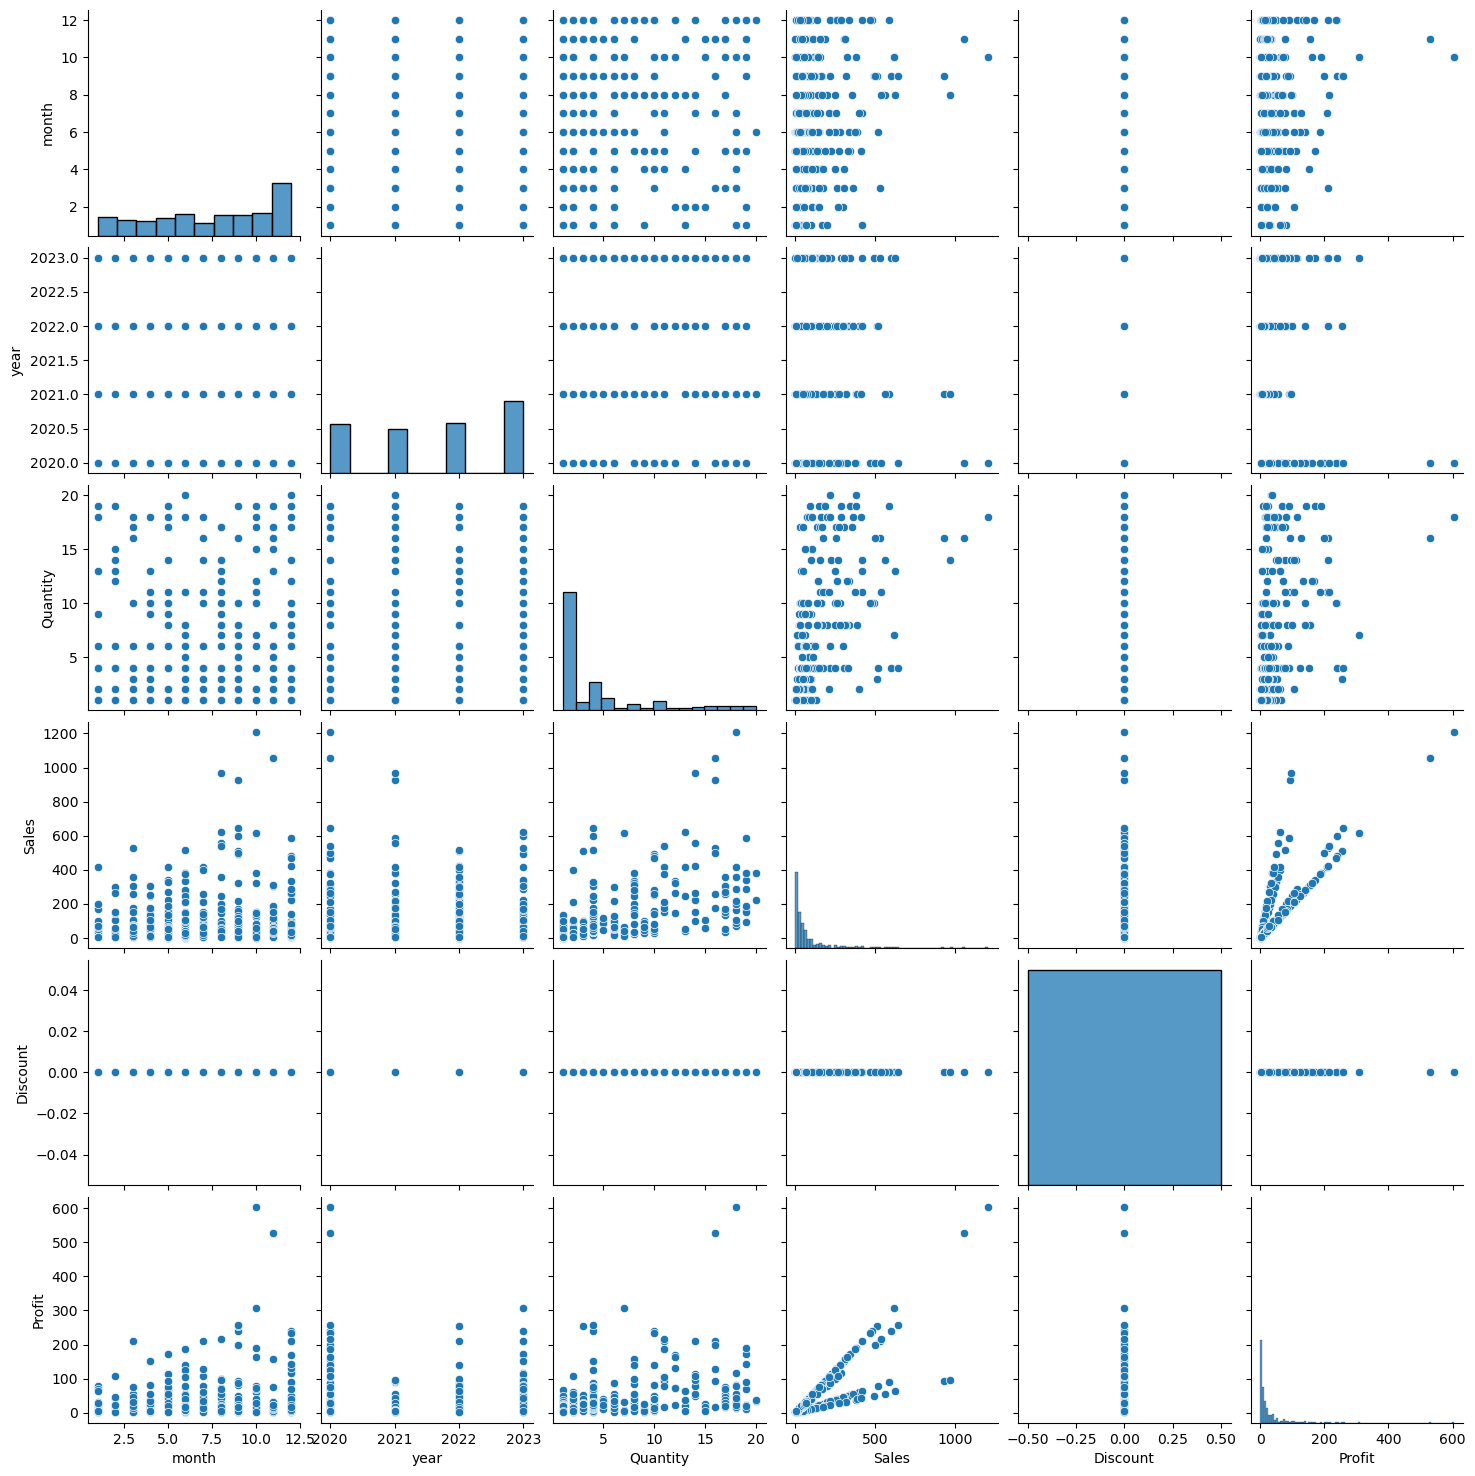

In [72]:
import seaborn as sns
sns.pairplot(df_egy);
plt.show()

we can visualize semi linear regression between sales and profit  in this dataframe  so we can estimate this by using linear regression model 

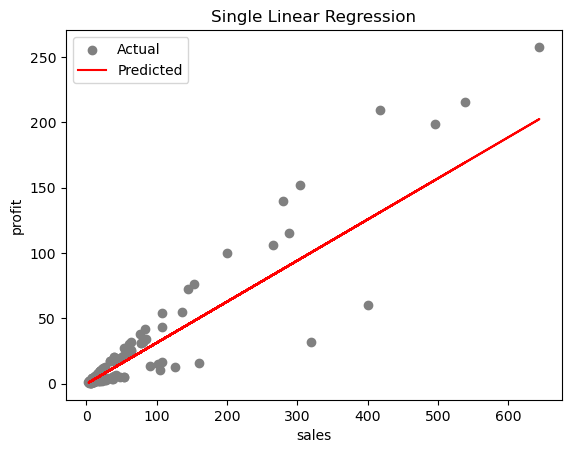

R² Score: 0.8380


In [110]:
X2 = df_egy[['Sales']]
y2 = df_egy[ 'Profit']

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='gray', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel("sales")
plt.ylabel("profit")
plt.title("Single Linear Regression")
plt.legend()
plt.show()

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

r2 score is not very good so we will try multible linear regression  for this dataset

In [111]:
X3 = df_egy[[ 'Quantity', 'Sales', 'Discount']]
y3 = df_egy['Profit']
X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [112]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

print("Coefficients:")
for name, coef in zip(X3.columns, model_multi.coef_):
    print(f"{name}: {coef:.2f}")

print(f"\nR² Score: {r2_score(y_test, y_pred):.4f}")

Coefficients:
Quantity: -0.81
Sales: 0.33
Discount: 0.00

R² Score: 0.8320


In [113]:
#polynomial regression model:

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [80]:
y_pred = poly_model.predict(X_test)
print(f"R² Score (Polynomial): {r2_score(y_test, y_pred):.4f}")

R² Score (Polynomial): 0.8052


In [114]:
#let's try other type of regression models(ridge)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)


Ridge()

In [115]:
y_pred = ridge.predict(X_test)
print(f"R² Score (Ridge): {r2_score(y_test, y_pred):.4f}")

R² Score (Ridge): 0.8320


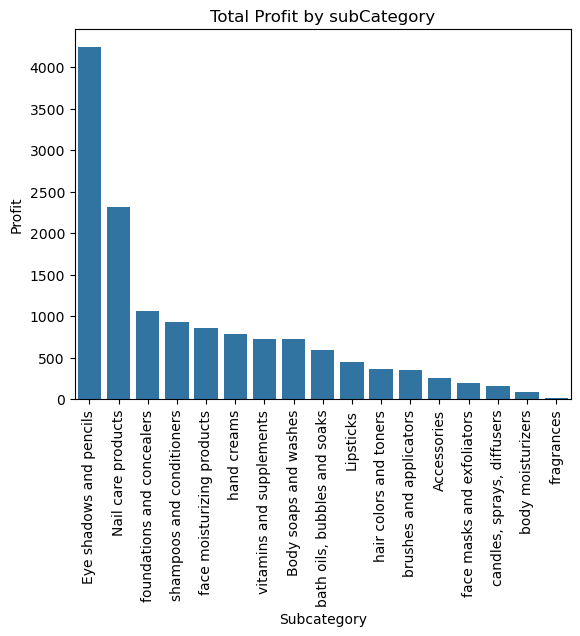

In [83]:
profit_per_category = (
    df_egy.groupby('Subcategory')['Profit']
    .sum()
    .reset_index()
    .sort_values('Profit', ascending=False)
)

sns.barplot(data=profit_per_category, x='Subcategory', y='Profit')
plt.xticks(rotation=90)
plt.title('Total Profit by subCategory')
plt.show()

In [85]:
    df_egy['Customer ID'].value_counts()


Customer ID
HG-502538     8
MC-763538     8
KL-655538     8
BH-171038     7
LS-694538     7
             ..
TB-1125038    1
BS-136538     1
DB-306038     1
EL-373538     1
DS-303038     1
Name: count, Length: 214, dtype: int64

In [105]:
#extracting datafram of loreal products for further analysis

df_loreal = df_egy[df_egy['Product'].str.contains("L'Oréal", case=False, na=False)]
df_loreal 

,Customer ID,month,year,Segment,City,State,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit,Month_Name
2201,AH-69038,11,2023,Corporate,Cairo,Al Qahirah,Africa,"bath oils, bubbles and soaks",Body care,L'Oréal Paris EverPure Sulfate-Free Moisture C...,15,60,0.0,24.00,November
4430,NP-870038,10,2023,Consumer,Al Minya,Al Minya,Africa,body moisturizers,Body care,L'Oréal Infallible 24HR Eyeshadow Midnight Blue,1,17,0.0,1.70,October
7169,NM-844538,9,2023,Self-Employed,Cairo,Al Qahirah,Africa,face masks and exfoliators,Body care,L'Oréal Paris Elvive Total Repair 5 Shampoo,2,28,0.0,2.80,September
12962,JW-595538,5,2023,Consumer,Alexandria,Al Iskandariyah,Africa,Nail care products,Body care,L'Oréal Paris Hydra Genius Liquid Care Daily M...,2,60,0.0,30.00,May
13520,BF-97538,5,2023,Corporate,Alexandria,Al Iskandariyah,Africa,Nail care products,Body care,L'Oréal Paris Elvive Fibrology Thickening Cond...,11,187,0.0,93.50,May
16124,LC-688538,2,2023,Consumer,Alexandria,Al Iskandariyah,Africa,Nail care products,Body care,L'Oréal Infallible 24HR Eyeshadow Smoldering Plum,4,24,0.0,9.60,February
17540,RM-937538,12,2022,Consumer,Cairo,Al Qahirah,Africa,Nail care products,Body care,L'Oréal Paris Wrinkle Expert 35+ Moisturizer,6,54,0.0,21.60,December
22510,MK-816038,9,2022,Consumer,Cairo,Al Qahirah,Africa,face moisturizing products,Face care,L'Oréal Paris Age Perfect Hydra-Nutrition Manu...,8,168,0.0,84.00,September
23425,LS-694538,9,2022,Corporate,Alexandria,Al Iskandariyah,Africa,face moisturizing products,Face care,L'Oréal Colour Riche Monos Eyeshadow Matte-Iso...,5,85,0.0,34.00,September
24118,VF-1171538,8,2022,Self-Employed,Cairo,Al Qahirah,Africa,face moisturizing products,Face care,L'Oréal Infallible 24HR Eyeshadow Bronzed Taupe,4,44,0.0,17.60,August


In [106]:
df_loreal .info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 2201 to 48589
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  33 non-null     object 
 1   month        33 non-null     int64  
 2   year         33 non-null     int64  
 3   Segment      33 non-null     object 
 4   City         33 non-null     object 
 5   State        33 non-null     object 
 6   Market       33 non-null     object 
 7   Subcategory  33 non-null     object 
 8   Category     33 non-null     object 
 9   Product      33 non-null     object 
 10  Quantity     33 non-null     int64  
 11  Sales        33 non-null     int64  
 12  Discount     33 non-null     float64
 13  Profit       33 non-null     float64
 14  Month_Name   33 non-null     object 
dtypes: float64(2), int64(4), object(9)
memory usage: 4.1+ KB


In [108]:
df_loreal.to_excel('loreal.xlsx',index=False)

In [87]:
#making dataframe showing customers who made orders more than 20 
df_egy_customer = df_egy[df_egy['Customer ID'].isin(
    df_egy['Customer ID'].value_counts()[lambda x: x > 5].index)]
df_egy_customer

,Customer ID,month,year,Segment,City,State,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit,Month_Name
1444,JF-556538,12,2023,Consumer,Hurghada,Al Bahr Al Ahmar,Africa,"bath oils, bubbles and soaks",Body care,Jergens Hydrating Coconut Moisturizer,1,16,0.0,8.0,December
1467,SC-1044038,12,2023,Corporate,Alexandria,Al Iskandariyah,Africa,"bath oils, bubbles and soaks",Body care,Aveda Shampure Composition Oil,8,24,0.0,12.0,December
2471,HG-502538,11,2023,Consumer,Alexandria,Al Iskandariyah,Africa,body moisturizers,Body care,Too Faced Natural Eyes Palette Nudie,2,16,0.0,1.6,November
2839,CR-262538,11,2023,Self-Employed,Tanta,Al Gharbiyah,Africa,body moisturizers,Body care,Butter London Nail Lacquer Slapper Bright Teal,1,7,0.0,0.7,November
3393,BH-171038,11,2023,Consumer,Cairo,Al Qahirah,Africa,body moisturizers,Body care,New Chapter Collagen Peptides,1,49,0.0,4.9,November
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48872,PT-909038,5,2020,Consumer,Cairo,Al Qahirah,Africa,foundations and concealers,Make up,Garnier Olia Bold - Medium Rose Gold,1,17,0.0,6.8,May
49599,HG-502538,4,2020,Consumer,Alexandria,Al Iskandariyah,Africa,Lipsticks,Make up,Clairol Natural Instincts - Medium Cool Blonde,6,66,0.0,33.0,April
49865,BH-171038,4,2020,Consumer,Cairo,Al Qahirah,Africa,Lipsticks,Make up,Maybelline Color Tattoo 24HR Eyeshadow Silver ...,1,9,0.0,4.5,April
50081,CM-216038,3,2020,Consumer,Cairo,Al Qahirah,Africa,Lipsticks,Make up,Garden of Life Elderberry Gummies,4,152,0.0,76.0,March


In [89]:
df_egy_customer[ 'City'].value_counts()

City
Alexandria    30
Cairo         30
Hurghada      14
Port Said      4
Tanta          2
Name: count, dtype: int64

In [96]:
df_customer_products =pd.crosstab(df_egy_customer[ 'Customer ID'],df_egy_customer[ 'Subcategory'])
df_customer_products

Subcategory,Accessories,Body soaps and washes,Eye shadows and pencils,Lipsticks,Nail care products,"bath oils, bubbles and soaks",body moisturizers,brushes and applicators,"candles, sprays, diffusers",face masks and exfoliators,face moisturizing products,foundations and concealers,hair colors and toners,hand creams,shampoos and conditioners,vitamins and supplements
Customer ID,,,,,,,,,,,,,,,,
BH-171038,0,0,1,1,1,0,2,0,0,1,0,0,0,0,1,0
CM-216038,1,0,0,1,1,0,0,0,2,0,0,0,0,0,1,0
CR-262538,0,0,0,0,2,0,1,0,0,0,2,0,0,0,1,0
HG-502538,0,0,1,1,3,0,1,0,0,0,0,1,0,0,1,0
JF-556538,0,1,1,0,2,1,0,0,0,0,0,0,0,0,1,0
KH-651038,0,0,3,0,1,0,0,0,0,0,0,0,1,0,1,0
KL-655538,1,0,2,0,1,0,0,0,1,0,0,0,0,1,2,0
LC-688538,0,0,2,0,1,0,0,0,0,1,1,0,0,1,0,0
LS-694538,1,0,1,1,2,0,0,1,0,0,1,0,0,0,0,0


In [99]:
#here we have an excel sheet contains top customers in Egypt and thier favourite subcategories


df_customer_products.to_excel('top_customers.xlsx', index=False)
